## lib

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## data preprocessing

### Training image preprocessing

In [7]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 70295 files belonging to 38 classes.


### Validate image preprocessing

In [10]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [12]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [14]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[140.25 123.25 113.25]
   [139.5  122.5  112.5 ]
   [141.   124.   114.  ]
   ...
   [166.   153.   145.  ]
   [147.75 134.75 126.75]
   [146.5  133.5  125.5 ]]

  [[141.25 124.25 114.25]
   [145.25 128.25 118.25]
   [143.   126.   116.  ]
   ...
   [156.25 143.25 135.25]
   [156.75 143.75 135.75]
   [160.75 147.75 139.75]]

  [[150.75 133.75 123.75]
   [146.   129.   119.  ]
   [146.25 129.25 119.25]
   ...
   [153.75 140.75 132.75]
   [164.5  151.5  143.5 ]
   [145.25 132.25 124.25]]

  ...

  [[167.   160.   152.  ]
   [155.75 148.75 140.75]
   [167.   160.   152.  ]
   ...
   [177.75 170.75 164.75]
   [160.5  153.5  147.5 ]
   [178.   171.   165.  ]]

  [[160.5  153.5  145.5 ]
   [157.5  150.5  142.5 ]
   [159.25 152.25 144.25]
   ...
   [172.25 165.25 159.25]
   [173.25 166.25 160.25]
   [167.   160.   154.  ]]

  [[162.5  155.5  147.5 ]
   [159.75 152.75 144.75]
   [159.5  152.5  144.5 ]
   ...
   [188.25 181.25 175.25]
   [187.75 180.75 174.75]
   [174.25 167.25 16

### to avoid overshooting
1.choose a small learning rate 
2.There may be a chance of underfitting, so increase number of neuron
3.Add more convolution layer to extract more feature from images there may be possibility that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## building model

In [58]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [60]:
model=Sequential()

In [62]:
#building cnn layer

In [64]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [66]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [68]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [70]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [72]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [74]:
model.add(Dropout(0.25)) #to avoid overfitting

In [76]:
model.add(Flatten())

In [78]:
model.add(Dense(units=1500,activation='relu'))

In [80]:
model.add(Dropout(0.4))

In [82]:
#output layer
model.add(Dense(units=38,activation='softmax'))

### compiling model

In [87]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [89]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### model training

In [92]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1017s 463ms/step - accuracy: 0.6120 - loss: 1.3129 - val_accuracy: 0.8412 - val_loss: 0.5090
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1052s 479ms/step - accuracy: 0.8629 - loss: 0.4338 - val_accuracy: 0.8794 - val_loss: 0.3693
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1026s 467ms/step - accuracy: 0.9153 - loss: 0.2574 - val_accuracy: 0.9162 - val_loss: 0.2591
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1039s 473ms/step - accuracy: 0.9421 - loss: 0.1751 - val_accuracy: 0.9496 - val_loss: 0.1575
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1011s 460ms/step - accuracy: 0.9572 - loss: 0.1301 - val_accuracy: 0.9471 - val_loss: 0.1793
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 992s 452ms/step - accuracy: 0.9661 - loss: 0.1031 - val_accuracy: 0.9567 - val_loss: 0.1431
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1045s 476ms/step - accuracy: 0.9727 - loss: 0.0838 - val_accuracy: 0.9593 - val_loss: 0.1303
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1056s 481ms/st

### Model Evaluation

In [95]:
#model evaluation on training set
train_loss,train_acc=model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 263s 120ms/step - accuracy: 0.9901 - loss: 0.0310


In [97]:
print(train_loss,train_acc)

0.03103385865688324 0.9900846481323242


In [99]:
#model on validation set
val_loss,val_acc=model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 62s 113ms/step - accuracy: 0.9659 - loss: 0.1240


In [101]:
print(val_loss,val_acc)

0.1239800900220871 0.9659116864204407


### Saving Model

In [104]:
model.save("trained_model.h5")

In [106]:
model.save("trained_model.keras")

In [108]:
training_history.history

{'accuracy': [0.6120492219924927,
  0.8629205226898193,
  0.9153140187263489,
  0.9420726895332336,
  0.9571662545204163,
  0.9660999774932861,
  0.9727434515953064,
  0.9766839742660522,
  0.9808236956596375,
  0.982146680355072],
 'loss': [1.312859296798706,
  0.43379542231559753,
  0.257351815700531,
  0.1750907152891159,
  0.13010665774345398,
  0.10313717275857925,
  0.08379721641540527,
  0.07069899886846542,
  0.06077371537685394,
  0.05502965301275253],
 'val_accuracy': [0.8412246704101562,
  0.8793535232543945,
  0.9162303805351257,
  0.9496358036994934,
  0.9471318125724792,
  0.9567493796348572,
  0.9593102931976318,
  0.9627248048782349,
  0.9711472988128662,
  0.9659116864204407],
 'val_loss': [0.5089598298072815,
  0.3693060576915741,
  0.25914421677589417,
  0.15750713646411896,
  0.1793312430381775,
  0.14305885136127472,
  0.13028016686439514,
  0.12706045806407928,
  0.09604018926620483,
  0.1239800900220871]}

In [121]:
#Recording history in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [123]:
training_history.history['val_accuracy']

[0.8412246704101562,
 0.8793535232543945,
 0.9162303805351257,
 0.9496358036994934,
 0.9471318125724792,
 0.9567493796348572,
 0.9593102931976318,
 0.9627248048782349,
 0.9711472988128662,
 0.9659116864204407]

### Accuracy Visualization 

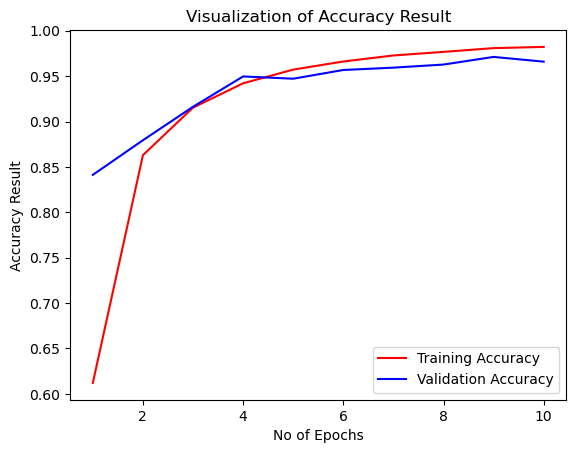

In [127]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Model evaluation



In [130]:
class_name=validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [132]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [135]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 63s 115ms/step


(array([[9.9999881e-01, 1.3959973e-08, 2.1138811e-09, ..., 2.8356804e-13,
         9.9214257e-13, 1.2546314e-11],
        [1.0000000e+00, 1.6335462e-11, 1.2334160e-11, ..., 1.4928444e-17,
         5.8476938e-17, 1.4659052e-15],
        [9.9999964e-01, 1.3470631e-09, 9.0733208e-09, ..., 1.0457309e-14,
         2.8097125e-12, 1.5873598e-11],
        ...,
        [1.8683005e-10, 1.8896833e-12, 3.3573508e-09, ..., 4.5346567e-11,
         1.1986785e-10, 9.9999809e-01],
        [8.1807172e-11, 1.2369441e-12, 9.2032548e-10, ..., 5.6981021e-11,
         4.3409939e-11, 9.9999976e-01],
        [3.7146534e-17, 1.5083097e-19, 1.1256085e-16, ..., 6.4444490e-17,
         3.7539860e-16, 1.0000000e+00]], shape=(17572, 38), dtype=float32),
 (17572, 38))

In [137]:
predicted_categories=tf.argmax(y_pred,axis=1)

In [139]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [141]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [143]:
y_true=tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [149]:
pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl (8.7 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [157]:
from sklearn.metrics import classification_report,confusion_matrix

In [153]:
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.95      0.96       504
                                 Apple___Black_rot       1.00      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.99      0.97      0.98       440
                                   Apple___healthy       0.96      0.98      0.97       502
                               Blueberry___healthy       0.96      0.99      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.98       421
                 Cherry_(including_sour)___healthy       0.98      0.96      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.94      0.94       410
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.96      0.

In [159]:
cm=confusion_matrix(y_true,predicted_categories)
cm.shape

(38, 38)

### Visualization of Confusion Matrix



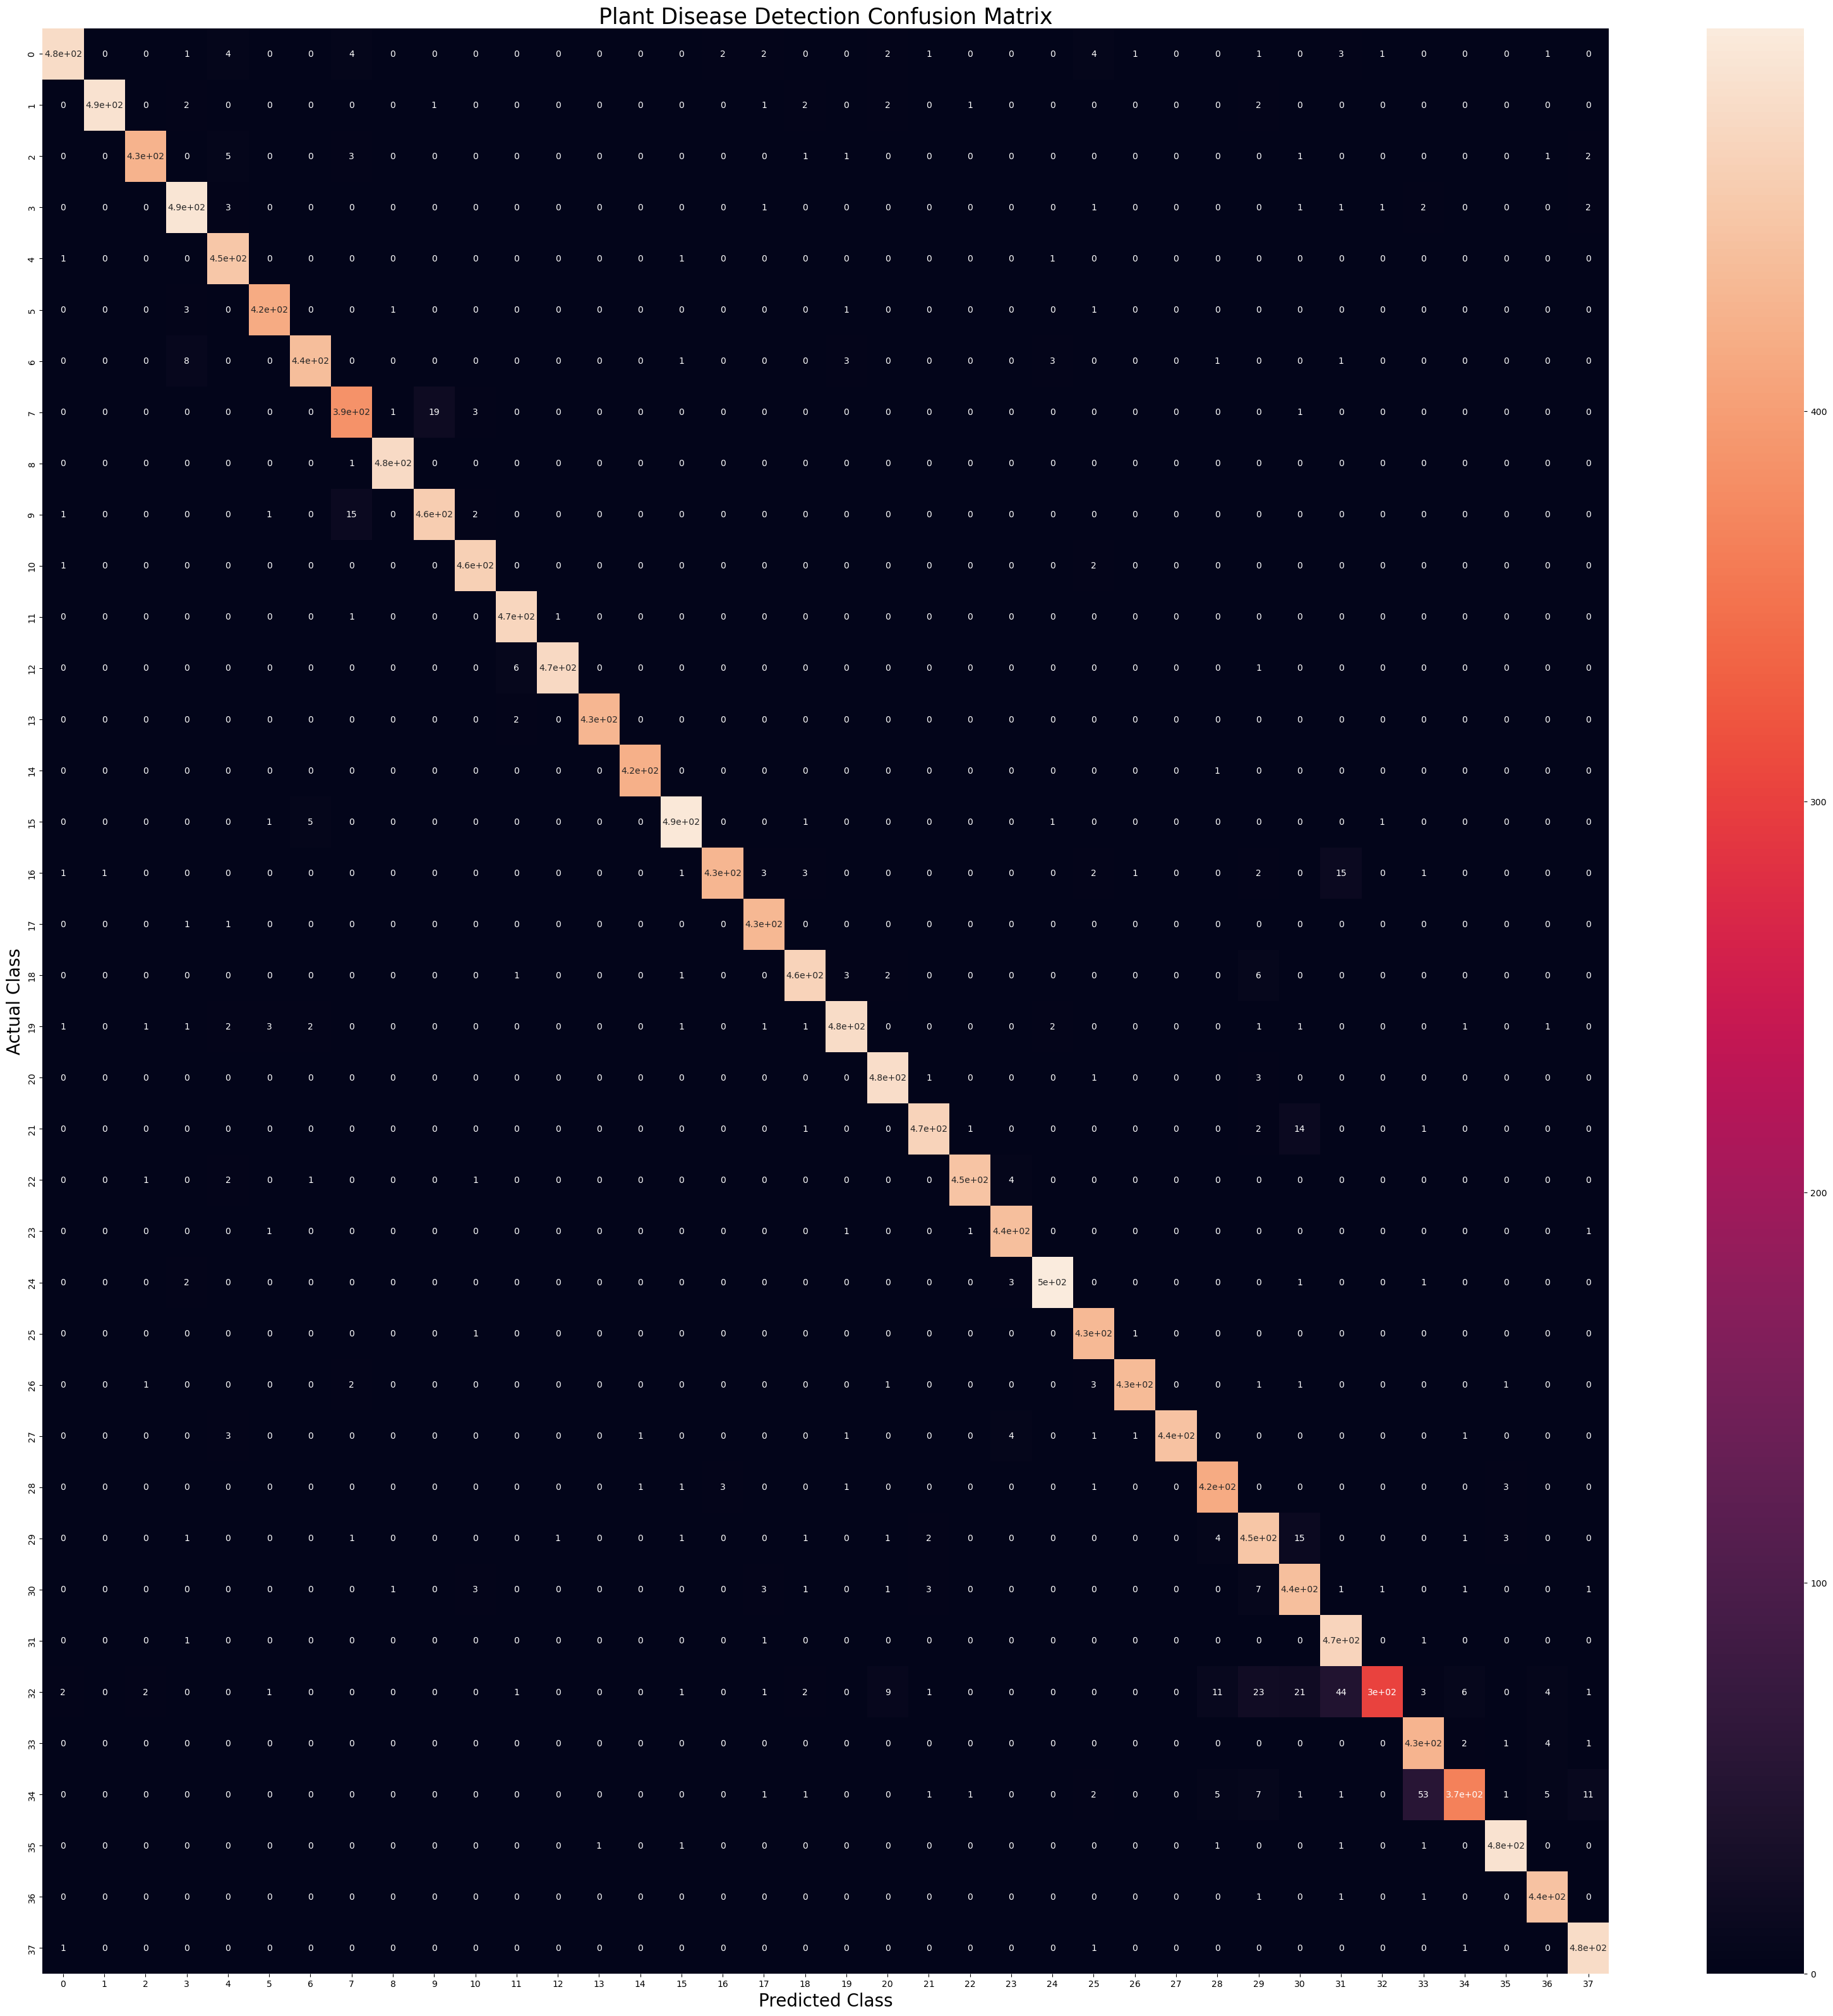

In [178]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Detection Confusion Matrix",fontsize=25)
plt.show()